##Name: Anush Acharya
##Student ID: 2406798
##Worksheet 5

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os


drive_path = '/content/drive/MyDrive/FruitInAmazon/'

try:
    print(f"Contents of {drive_path}:")
    for item in os.listdir(drive_path):
        print(item)
except FileNotFoundError:
    print(f"Error: The directory '{drive_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")


Contents of /content/drive/MyDrive/FruitInAmazon/:
FruitinAmazon.zip
FruitAmazon_extracted


In [19]:
import zipfile
import os

zip_file_path = '/content/drive/MyDrive/FruitInAmazon/FruitinAmazon.zip'
extract_dir = '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted'


os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Successfully unzipped '{zip_file_path}' to '{extract_dir}'.")
except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found. Please check the path.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully unzipped '/content/drive/MyDrive/FruitInAmazon/FruitinAmazon.zip' to '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted'.


In [20]:
import os

extracted_data_path = '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted'

print(f"Contents of {extracted_data_path}:")

try:

    for item in os.listdir(extracted_data_path):
        print(item)

    print(f"Error: The directory '{extracted_data_path}' was not found.")
except Exception as e:
    print(f"An error occurred while listing directory contents: {e}")


Contents of /content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted:
FruitinAmazon
Error: The directory '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted' was not found.


In [21]:
import tensorflow as tf


train_dir = '/content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted/FruitinAmazon/train'


img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
seed = 123

print(f"Training data directory set to: {train_dir}")
print(f"Using images of size {img_height}x{img_width} with a batch size of {batch_size}.")

Training data directory set to: /content/drive/MyDrive/FruitInAmazon/FruitAmazon_extracted/FruitinAmazon/train
Using images of size 224x224 with a batch size of 32.


## Task 1.1 – Visualize Images

This task involves importing necessary libraries, listing class names from the `train_dir`, and then displaying a random image from each class to get a visual understanding of the dataset.

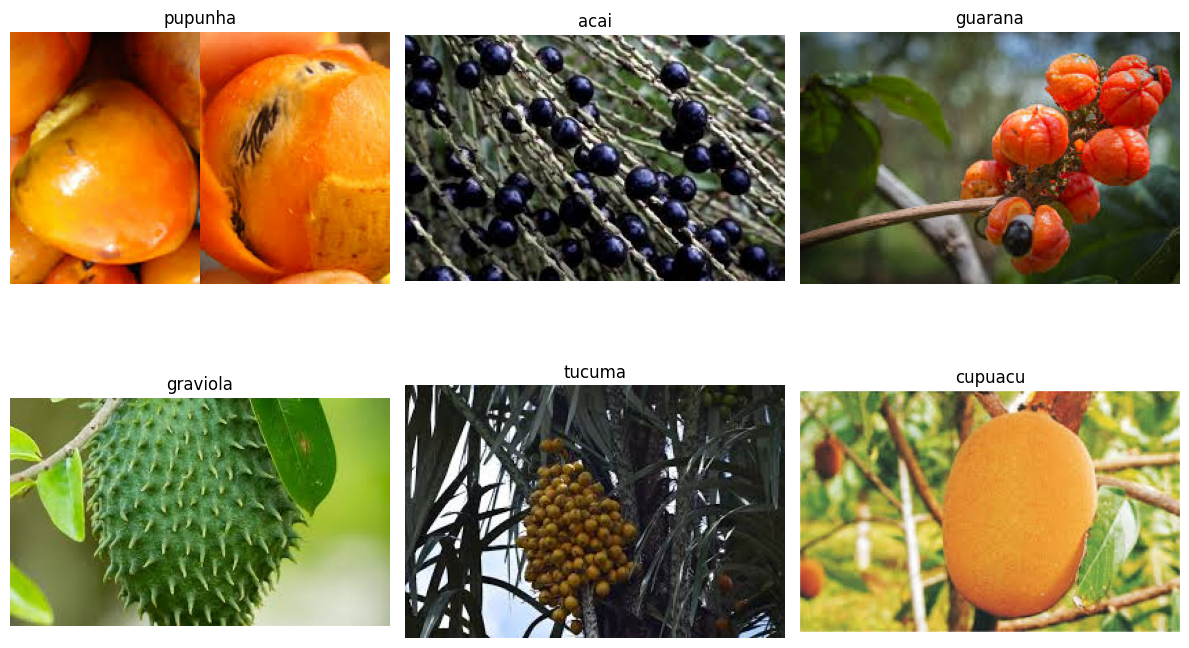

In [22]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image



class_names_for_viz = os.listdir(train_dir)

plt.figure(figsize=(12, 8))


num_classes_viz = len(class_names_for_viz)
num_cols = 3
num_rows = (num_classes_viz + num_cols - 1) // num_cols

for i, class_name in enumerate(class_names_for_viz):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        img_files = os.listdir(class_path)
        if img_files:
            img_name = random.choice(img_files)
            img_path = os.path.join(class_path, img_name)

            img = Image.open(img_path)

            plt.subplot(num_rows, num_cols, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
        else:
            print(f"Warning: No images found in {class_path}")
    else:
        print(f"Warning: {class_path} is not a directory.")

plt.tight_layout()
plt.show()

## Task 1.2 – Remove Corrupted Images

This step iterates through all images in the training directory, attempts to open and verify them using PIL. If an image is found to be corrupted (e.g., `IOError` or `SyntaxError`), it is removed from the directory.

In [23]:
import os
from PIL import Image

corrupted_images = []


print("Checking for corrupted images...")
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path} - Error: {e}")
            except Exception as e:
                print(f"An unexpected error occurred with {img_path}: {e}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print(f"Found and removed {len(corrupted_images)} corrupted images.")

Checking for corrupted images...
No corrupted images found.


## Task 2 – Load & Preprocess Dataset

This task re-defines image dimensions and batch size, then uses `tf.keras.preprocessing.image_dataset_from_directory` to load the training and validation datasets. It also includes a `Rescaling` layer for image normalization and updates `class_names` and `num_classes`.

In [24]:
import tensorflow as tf

# Define image dimensions and batch size
img_width = 128
batch_size = 32
validation_split = 0.2
seed = 123
# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

print(f"Loading datasets with image size {img_height}x{img_width} and batch size {batch_size}...")

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

# Retrieve class_names BEFORE applying .cache().prefetch()
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print(f"Number of classes: {num_classes}")

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Optimize for performance with cache() and prefetch()
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Loading datasets with image size 128x128 and batch size 32...
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


## Task 3 – Build CNN Model

This task constructs a Convolutional Neural Network (CNN) model using `tf.keras.Sequential`. The model consists of convolutional layers, max-pooling layers, flatten layer, and dense (fully connected) layers, ending with a softmax activation for classification.

In [25]:
from tensorflow import keras
from tensorflow.keras import layers



print("Building the CNN model...")
model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Fully Connected layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Building the CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4 – Compile Model

This task configures the model for training using the `compile` method. It specifies the optimizer (`adam`), loss function (`sparse_categorical_crossentropy`), and metrics to monitor during training (`accuracy`).

In [26]:
print("Compiling the model...")
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Compiling the model...
Model compiled successfully.


## Task 4 – Train Model (with Callbacks)

This task initiates the training process for the compiled model. It includes `ModelCheckpoint` to save the best model weights based on validation accuracy and `EarlyStopping` to prevent overfitting by monitoring validation loss. Training will run for up to 250 epochs, with a batch size of 16 for the `model.fit` function.

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("Starting model training...")

# Callbacks
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

print("Model training completed.")

Starting model training...
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2263 - loss: 2.1500
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 593ms/step - accuracy: 0.1944 - loss: 2.2978 - val_accuracy: 0.0000e+00 - val_loss: 1.7764
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.1881 - loss: 1.8695
Epoch 2: val_accuracy improved from 0.00000 to 0.38889, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 449ms/step - accuracy: 0.2361 - loss: 1.8263 - val_accuracy: 0.3889 - val_loss: 1.5657
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.4346 - loss: 1.6182
Epoch 3: val_accuracy did not improve from 0.38889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.4444 - loss: 1.5700 - val_accuracy: 0.1111 - val_loss: 1.7262
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.4184 - loss: 1.4372
Epoch 4: val_accuracy improved from 0.38889 to 0.61111, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 788ms/step - accuracy: 0.4583 - loss: 1.3871 - val_accuracy: 0.6111 - val_loss: 1.3842
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.6539 - loss: 1.1819
Epoch 5: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 781ms/step - accuracy: 0.6806 - loss: 1.1123 - val_accuracy: 0.6111 - val_loss: 1.1473
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7095 - loss: 0.9712
Epoch 6: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.7222 - loss: 0.9098 - val_accuracy: 0.6111 - val_loss: 1.1000
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.7483 - loss: 0.7955
Epoch 7: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.7917 - loss: 0.7180 - val_accuracy: 0.6111 - val_loss: 0.7714
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 507ms/step - accuracy: 0.7888 - loss: 0.641


Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 603ms/step - accuracy: 0.8194 - loss: 0.5741 - val_accuracy: 0.8889 - val_loss: 0.5903
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9196 - loss: 0.4339
Epoch 9: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step - accuracy: 0.9306 - loss: 0.3938 - val_accuracy: 0.7222 - val_loss: 0.8117
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8686 - loss: 0.4611
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 565ms/step - accuracy: 0.9028 - loss: 0.3695 - val_accuracy: 0.8889 - val_loss: 0.6990
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9190 - loss: 0.3654
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9444 - loss: 0.2932 - val_accuracy: 0.8333 - val_loss: 0.5996
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.8791 - loss: 0.5065


Epoch 14: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 471ms/step - accuracy: 0.9306 - loss: 0.2002 - val_accuracy: 0.9444 - val_loss: 0.2835
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.8889 - loss: 0.2262
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step - accuracy: 0.9167 - loss: 0.1941 - val_accuracy: 0.9444 - val_loss: 0.1910
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 1.0000 - loss: 0.0455
Epoch 16: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 400ms/step - accuracy: 1.0000 - loss: 0.0386 - val_accuracy: 0.7778 - val_loss: 0.5582
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9797 - loss: 0.0550
Epoch 17: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.9861 - loss: 0.0460 - val_accuracy: 0.8333 - val_loss: 0.8430
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 1.0000 - los

## Plot Accuracy & Loss Graphs

This task visualizes the training and validation accuracy and loss over epochs. These plots are crucial for understanding the model's performance and identifying potential overfitting or underfitting.

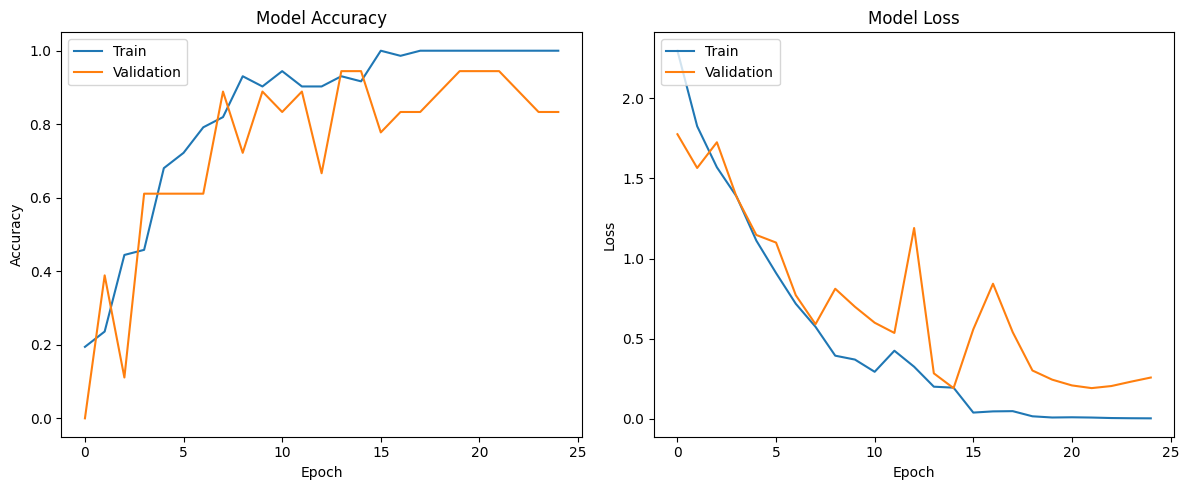

In [27]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


## Task 5 – Evaluate Model

This task evaluates the trained model's performance on the validation dataset to measure its generalization capability. It prints the final loss and accuracy on the validation set.

In [28]:
print("Evaluating the model on the validation dataset...")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

Evaluating the model on the validation dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step - accuracy: 0.0000e+00 - loss: 1.7508
Validation Loss: 1.7508
Validation Accuracy: 0.0000


## Task 6 – Save & Load Model

This task demonstrates how to save the trained model to a file and then load it back. This is essential for deploying the model or continuing training later without rebuilding it from scratch.

In [29]:
import tensorflow as tf

# Save the model
model_save_path = "final_model.h5"
print(f"Saving model to {model_save_path}...")
model.save(model_save_path)
print("Model saved successfully.")

# Load the model
print(f"Loading model from {model_save_path}...")
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully.")

# You can optionally verify the loaded model
# loaded_model.summary()

Saving model to final_model.h5...
Model saved successfully.
Loading model from final_model.h5...
Model loaded successfully.


## Task 7 – Prediction + Classification Report

This final task uses the trained model to make predictions on the validation dataset and then generates a detailed classification report. The report includes precision, recall, f1-score, and support for each class, providing a comprehensive view of the model's performance.

In [16]:
import numpy as np
from sklearn.metrics import classification_report


y_true = []
y_pred = []

print("Making predictions on the validation dataset...")

for images, labels in val_ds:

    preds = loaded_model.predict(images)
    # Convert probabilities to class labels
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Generating classification report...")

print(classification_report(y_true, y_pred, target_names=class_names, labels=range(num_classes)))


Making predictions on the validation dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
Generating classification report...
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.94      1.00      0.97        15

    accuracy                           0.94        18
   macro avg       0.32      0.28      0.29        18
weighted avg       0.95      0.94      0.94        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me